# AI Waste Sorter

### Project Overview
In this project we try to build an AI model that can classify the kind of waste into 12 classes from images.

# EfficientNetB0 Transfer Learning

This project will use various transfer learning models. We will use MobileNetV2 and EfficientNet-b0 as transfer learning models and then compare the performance. For this notebook we will use EfficientNet-b0 transfer learning model.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime
import gc

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

if tf.config.list_physical_devices('GPU'):
    print("Using GPU")
    for gpu in tf.config.list_physical_devices('GPU'):
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("Using CPU")

2026-02-05 22:11:37.456127: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using GPU


## 1. Configuration & Setup

In [2]:
BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR / 'processed_data'
TRAIN_DIR = PROCESSED_DIR / 'train_balanced'
VAL_DIR = PROCESSED_DIR / 'val'
TEST_DIR = PROCESSED_DIR / 'test'
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 100
NUM_CLASSES = 12

print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")

Image size: (224, 224)
Batch size: 32
Epochs: 100


## 2. Data Generators with Augmentation

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Train samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 8424 images belonging to 12 classes.
Found 1550 images belonging to 12 classes.
Found 1556 images belonging to 12 classes.
Train samples: 8424
Validation samples: 1550
Test samples: 1556


# 3. Transfer Learning Model

For this transfer learning model we will use EfficientNet-b0 with imagenet weights and freeze the base model

In [4]:
def create_efficientnetb0_model(input_shape=(224, 224, 3), num_classes=12):
    """
    Create EfficientNetB0 model with transfer learning
    """
    base_model = EfficientNetB0(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        pooling='avg'
    )
    
    base_model.trainable = False
    
    model = models.Sequential([
        base_model,
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ], name='EfficientNetB0_Transfer')
    
    return model, base_model

model, base_model = create_efficientnetb0_model()
print(f"\nBase model (EfficientNetB0) layers: {len(base_model.layers)}")
print(f"Base model trainable: {base_model.trainable}")
model.summary()

I0000 00:00:1770304347.323853    1490 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6



Base model (EfficientNetB0) layers: 239
Base model trainable: False


Model: "EfficientNetB0_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,413,487 (16.84 MB)

 Trainable params: 363,148 (1.39 MB)

 Non-trainable params: 4,050,339 (15.45 MB)

## 6. Training Configuration

In [5]:
def get_callbacks(model_name):
    model_path = MODELS_DIR / f'{model_name}_best.keras'
    
    callbacks_list = [
        callbacks.ModelCheckpoint(
            filepath=str(model_path),
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )
    ]
    
    return callbacks_list

print("Callbacks configured:")
print("- ModelCheckpoint to Save best model based on val_accuracy")
print("- ReduceLROnPlateau to Reduce LR by 0.5 if val_loss doesn't improve for 5 epochs")

Callbacks configured:
- ModelCheckpoint to Save best model based on val_accuracy
- ReduceLROnPlateau to Reduce LR by 0.5 if val_loss doesn't improve for 5 epochs


## 7. Phase 1: Train with Frozen Base Model

In [6]:
print("\nPhase 1: Train with frozen EfficientNetB0 base")
print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase1 = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=get_callbacks('efficientnetb0_phase1'),
    verbose=1
)

print(f"\nPhase 1 completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


Phase 1: Train with frozen EfficientNetB0 base
Started at: 2026-02-05 22:12:29
Epoch 1/30


2026-02-05 22:12:41.127813: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fda38013080 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-05 22:12:41.127847: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-02-05 22:12:41.501746: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-05 22:12:43.149407: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801
2026-02-05 22:12:43.896932: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-05 22:12:43.

  1/264 ━━━━━━━━━━━━━━━━━━━━ 2:43:15 37s/step - accuracy: 0.0625 - loss: 3.7838

2026-02-05 22:13:20.266950: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 22:13:20.462903: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 22:13:20.666369: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 22:13:20.851540: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 22:13:21.802782: E external/local_xla/xla/stream_

264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.0817 - loss: 3.1319

2026-02-05 22:15:08.103570: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 22:15:08.281366: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 22:15:08.469666: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 22:15:08.646375: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 22:15:09.509838: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from None to 0.04065, saving model to /mnt/d/personal/AI and Machine Learning/waste sorter ai/models/efficientnetb0_phase1_best.keras
264/264 ━━━━━━━━━━━━━━━━━━━━ 164s 483ms/step - accuracy: 0.0861 - loss: 2.9618 - val_accuracy: 0.0406 - val_loss: 2.6264 - learning_rate: 0.0010
Epoch 2/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.0817 - loss: 2.7456
Epoch 2: val_accuracy improved from 0.04065 to 0.05677, saving model to /mnt/d/personal/AI and Machine Learning/waste sorter ai/models/efficientnetb0_phase1_best.keras
264/264 ━━━━━━━━━━━━━━━━━━━━ 91s 345ms/step - accuracy: 0.0854 - loss: 2.7164 - val_accuracy: 0.0568 - val_loss: 2.4901 - learning_rate: 0.0010
Epoch 3/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.0851 - loss: 2.6446
Epoch 3: val_accuracy improved from 0.05677 to 0.06065, saving model to /mnt/d/personal/AI and Machine Learning/waste sorter ai/models/efficientnetb0_phase1_best.keras
264/264 ━━━━━━━━━━━━━━━━━━━━ 88s 

## 8. Phase 2: Fine-tuning with Unfrozen Top Layers

In [7]:
print("\nPhase 2: Fine-tuning with unfrozen top layers")
print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

base_model.trainable = True

fine_tune_at = 150
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Unfrozen layers from {fine_tune_at} onwards")
print(f"Total trainable layers: {sum([1 for layer in model.layers if layer.trainable])}")

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_generator,
    epochs=70,
    initial_epoch=30,
    validation_data=val_generator,
    callbacks=get_callbacks('efficientnetb0_final'),
    verbose=1
)

print(f"\nPhase 2 completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


Phase 2: Fine-tuning with unfrozen top layers
Started at: 2026-02-05 22:55:23
Unfrozen layers from 150 onwards
Total trainable layers: 8
Epoch 31/70


2026-02-05 22:55:45.232887: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 22:55:45.429954: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 22:55:45.613133: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 22:55:45.808531: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 22:55:45.997552: E external/local_xla/xla/stream_

221/264 ━━━━━━━━━━━━━━━━━━━━ 12s 293ms/step - accuracy: 0.1213 - loss: 2.4492

2026-02-05 22:57:10.304877: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 22:57:10.497244: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 22:57:10.674001: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 22:57:10.841951: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 22:57:11.041541: E external/local_xla/xla/stream_

264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.1224 - loss: 2.4441
Epoch 31: val_accuracy improved from None to 0.05484, saving model to /mnt/d/personal/AI and Machine Learning/waste sorter ai/models/efficientnetb0_final_best.keras
264/264 ━━━━━━━━━━━━━━━━━━━━ 152s 437ms/step - accuracy: 0.1287 - loss: 2.4146 - val_accuracy: 0.0548 - val_loss: 2.4721 - learning_rate: 1.0000e-04
Epoch 32/70
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.1658 - loss: 2.3547
Epoch 32: val_accuracy improved from 0.05484 to 0.14194, saving model to /mnt/d/personal/AI and Machine Learning/waste sorter ai/models/efficientnetb0_final_best.keras
264/264 ━━━━━━━━━━━━━━━━━━━━ 82s 311ms/step - accuracy: 0.1722 - loss: 2.3404 - val_accuracy: 0.1419 - val_loss: 2.3786 - learning_rate: 1.0000e-04
Epoch 33/70
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.2043 - loss: 2.2820
Epoch 33: val_accuracy did not improve from 0.14194
264/264 ━━━━━━━━━━━━━━━━━━━━ 85s 322ms/step - accuracy: 0.2168 

## 9. Training history plot

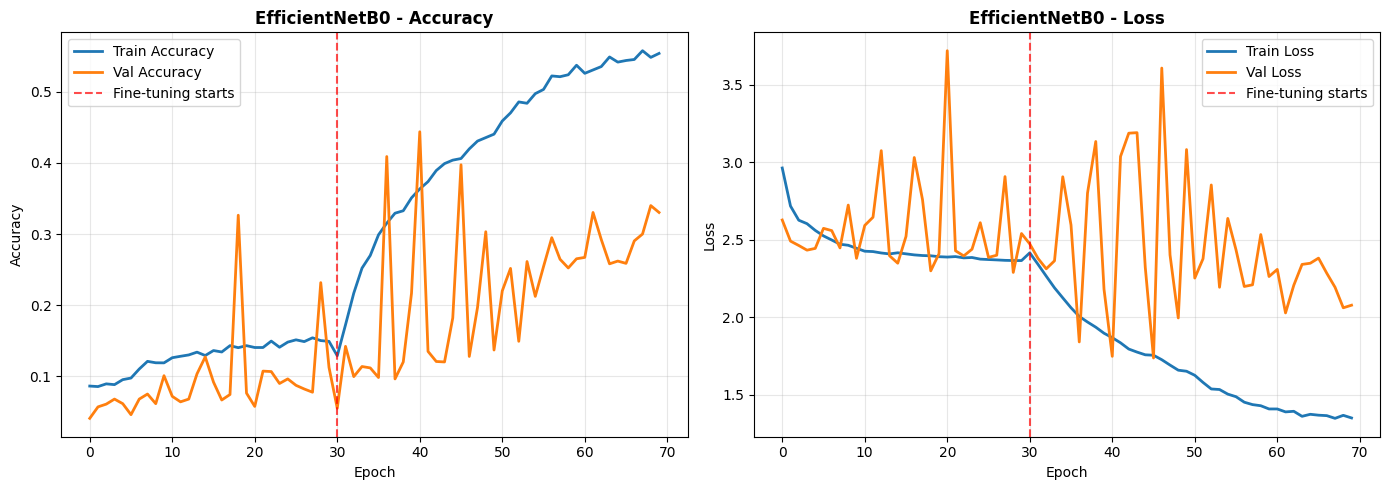

In [8]:
history_combined = {
    'accuracy': history_phase1.history['accuracy'] + history_phase2.history['accuracy'],
    'val_accuracy': history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy'],
    'loss': history_phase1.history['loss'] + history_phase2.history['loss'],
    'val_loss': history_phase1.history['val_loss'] + history_phase2.history['val_loss']
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_combined['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history_combined['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].axvline(x=30, color='red', linestyle='--', label='Fine-tuning starts', alpha=0.7)
axes[0].set_title('EfficientNetB0 - Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_combined['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history_combined['val_loss'], label='Val Loss', linewidth=2)
axes[1].axvline(x=30, color='red', linestyle='--', label='Fine-tuning starts', alpha=0.7)
axes[1].set_title('EfficientNetB0 - Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'efficientnetb0_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Save model and classification report

In [9]:
model.load_weights(str(MODELS_DIR / 'efficientnetb0_final_best.keras'))

test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

accuracy = accuracy_score(y_true, y_pred)

class_names = list(test_generator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)

print(f"\nEfficientNetB0 Test Accuracy: {accuracy:.4f}")
print(f"\nClassification Report:")
print(report)

48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step

2026-02-05 23:52:37.677533: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 23:52:37.873349: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 23:52:38.860579: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 23:52:39.079636: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 23:52:39.310121: E external/local_xla/xla/stream_

49/49 ━━━━━━━━━━━━━━━━━━━━ 29s 493ms/step

EfficientNetB0 Test Accuracy: 0.4557

Classification Report:
              precision    recall  f1-score   support

     battery     0.6667    0.3579    0.4658        95
  biological     0.2287    0.7879    0.3545        99
 brown-glass     0.5882    0.1639    0.2564        61
   cardboard     0.3037    0.6444    0.4128        90
     clothes     0.6247    0.8462    0.7187       533
 green-glass     1.0000    0.1429    0.2500        63
       metal     0.0000    0.0000    0.0000        77
       paper     0.2762    0.4762    0.3497       105
     plastic     0.2500    0.0115    0.0220        87
       shoes     0.4571    0.0808    0.1373       198
       trash     0.0000    0.0000    0.0000        70
 white-glass     0.4000    0.0256    0.0482        78

    accuracy                         0.4557      1556
   macro avg     0.3996    0.2948    0.2513      1556
weighted avg     0.4612    0.4557    0.3860      1556



## 11. Confussion matrix plot

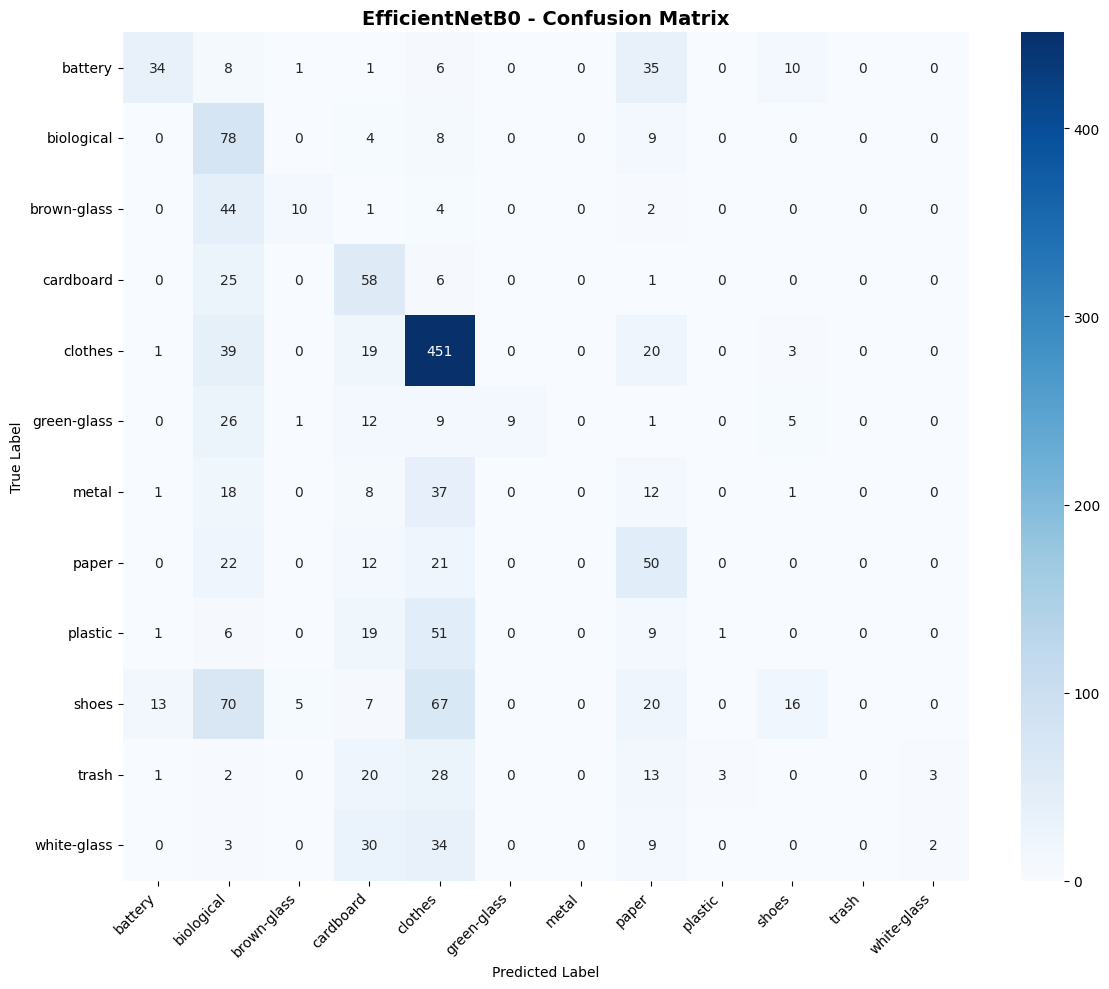

In [10]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('EfficientNetB0 - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'efficientnetb0_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Summary

In [11]:
results = {
    'model_name': 'EfficientNetB0',
    'model_type': 'Transfer Learning',
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'parameters': int(model.count_params()),
    'test_accuracy': float(accuracy),
    'best_val_accuracy': float(max(history_combined['val_accuracy'])),
    'final_train_accuracy': float(history_combined['accuracy'][-1]),
    'epochs_trained': len(history_combined['accuracy']),
    'training_phases': {
        'phase1_epochs': 30,
        'phase2_epochs': 70,
        'fine_tune_from_layer': 150
    },
    'configuration': {
        'image_size': IMG_SIZE,
        'batch_size': BATCH_SIZE,
        'max_epochs': EPOCHS,
        'base_model': 'EfficientNetB0',
        'pretrained_weights': 'imagenet'
    }
}

with open(MODELS_DIR / 'efficientnetb0_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\nSummary:")
print(f"Parameters: {results['parameters']:,}")
print(f"Test Accuracy: {results['test_accuracy']:.4f}")
print(f"Best Val Accuracy: {results['best_val_accuracy']:.4f}")
print(f"Epochs Trained: {results['epochs_trained']}")


Summary:
Parameters: 4,413,487
Test Accuracy: 0.4557
Best Val Accuracy: 0.4439
Epochs Trained: 70
